# Применение асимптотических методов и теории усреднения к динамике ИСЗ на низких орбитах


### Аннотация

В конспекте представлен обзор применения асимптотических методов и теории усреднения к исследованию динамики центра масс искусственных спутников Земли (ИСЗ) на низких околоземных орбитах (НОО). Рассмотрена хронология развития методов от классических канонических схем фон Цейпеля и модификаций Лиддана до прецизионных полуаналитических теорий (DSST, SGP4) и современных гибридных алгоритмов на основе преобразований Ли и физически информированных нейросетей (PINN). Особое внимание уделено математическим и физическим ограничениям асимптотического анализа в условиях НОО, включая проблему неконсервативного аэродинамического торможения, резонансы малых знаменателей (включая проблему критического наклонения) и координатные сингулярности уравнений Лагранжа. Сформулировано строгое математическое обоснование процедур усреднения на базе фундаментальных теорем Н.Н. Боголюбова и В.М. Волосова с оценкой погрешностей на асимптотическом интервале времени. Работа снабжена демонстрационной численной моделью в несингулярных равноденственных элементах, иллюстрирующей вычислительную эффективность полуаналитического подхода при долгосрочном прогнозировании эволюции орбит.

**Ключевые слова:** динамика ИСЗ, низкие околоземные орбиты, асимптотические методы, теория усреднения, геопотенциал, сопротивление атмосферы, полуаналитические теории, метод преобразований Ли, равноденственные элементы.


## Введение. Мотивация применения асимптотических подходов

Моделирование и долгосрочный прогноз движения искусственных спутников Земли (ИСЗ) на низких околоземных орбитах (НОО) сопряжены с высокими вычислительными затратами. Прямое численное интегрирование полных дифференциальных уравнений движения обеспечивает высокую точность на коротких интервалах времени. Однако при прогнозировании на месяцы и годы вперед численные методы сталкиваются с деградацией точности из-за накопления погрешностей округления на каждом мелком шаге интегрирования, необходимом для фиксации быстрых орбитальных колебаний. 

Асимптотические и строящиеся на их основе полуаналитические методы разрешают это противоречие. Путем разделения масштабов времени и математического исключения быстрых фаз они позволяют пренебречь краткопериодической «символьной» структурой уравнений и интегрировать эволюцию орбиты с крупным шагом. 

Для системного сопоставления существующих подходов ниже приведена сравнительная матрица, демонстрирующая баланс скорости, точности и области назначения каждого метода.

### Сравнительный обзор подходов к моделированию орбитальной динамики

| Критерий | Численные методы | Асимптотические (аналитические) методы | Полуаналитические методы |
| :--- | :--- | :--- | :--- |
| **Суть** | Пошаговое интегрирование полных уравнений движения | Построение явных функциональных формул-рядов от времени | Комбинация: аналитическое усреднение + численный шаг по медленным переменным |
| **Скорость** | Низкая (требует непрерывного расчета каждого витка полета) | **Максимальная** (мгновенный расчет параметров на любую заданную дату) | Высокая (шаг численного интегрирования может составлять несколько суток или недель) |
| **Точность** | Высокая на относительно коротких интервалах прогнозирования | Ограничена порядком разложения по малому параметру задачи | Высокая на сверхдлинных интервалах времени (за счет исключения накопления шаговых погрешностей) |
| **Назначение** | Оперативное управление, финальное наведение, маневрирование | Качественный анализ фазового пространства, проектирование спутниковых группировок | Долгосрочный прогноз эволюции космического мусора, вековая динамика орбит |

## 1. Исторический обзор и ключевые теоретические работы

Развитие аналитических и полуаналитических методов исследования эволюции орбит искусственных спутников Земли (ИСЗ) на низких околоземных орбитах (НОО) опирается на математический аппарат гамильтоновой механики и теории нелинейных колебаний. В хронологии развития данных методов выделяются три фундаментальных этапа:

### 1.1. Классический этап (Разделение периодических возмущений)

Основополагающие теории движения ИСЗ в гравитационном поле сжатой планеты, созданные на рубеже 1950–1960-х годов, базировались на концепции разделения разномасштабных динамических процессов и независимого исключения кратко- и долгопериодических составляющих. На данном этапе развитие получили следующие математические подходы:

* **Канонический метод фон Цейпеля (Брауэр, 1959):** Дирк Брауэр в работе [Brouwer, 1959] получил полное аналитическое решение задачи о движении ИСЗ под действием зональных гармоник геопотенциала ($J_2$–$J_5$) в канонических переменных Делоне. Этот подход оперировал производящими функциями от разноименных переменных для последовательного исключения из гамильтониана краткопериодических (зависящих от средней аномалии $M$) и долгопериодических (зависящих от аргумента перигея $\omega$) членов.
* **Неканонический метод усреднения (Козаи, 1959; Изсак, 1963):** Ёсихидэ Козаи [Kozai, 1959] и Имре Изсак [Izsak, 1963] параллельно и независимо разработали аналитическую теорию первого порядка в классических элементах Кеплера посредством прямого усреднения правых частей дифференциальных уравнений Лагранжа в вариациях элементов. Впоследствии Изсак [Izsak, 1963] расширил этот аппарат, получив аналитическое решение для тессеральных гармоник ($m \neq 0$), описывающих влияние долготной асимметрии масс Земли.
* **Линейная теория возмущений Каулы (1966):** фундаментальным прорывом в аналитическом описании гравитационных возмущений ИСЗ стала работа У. Каулы [Kaula, 1966], который разработал математический аппарат разложения геопотенциала произвольной степени $l$ и порядка $m$ в тригонометрический ряд по классическим элементам Кеплера. Внедрение нормализованных функций наклонения $F_{lmp}(i)$ и эксцентриситета $G_{lpq}(e)$ позволило получить в явном виде линейные аналитические поправки к элементам орбиты от любой высокочастотной тессеральной и секторальной гармоники. Монография «Theory of Satellite Geodesy» (1966) стала математической основой для последующего развития полуаналитических методов и алгоритмов прецизионного определения орбит ИСЗ.
* **Метод Волосова для неконсервативных систем (1962):** параллельно с развитием канонических подходов в небесной механике, В. М. Волосов [Волосов, 1962] разработал строгую математическую схему усреднения для общих нелинейных неконсервативных дифференциальных систем с быстрыми и медленными переменными. Этот аппарат стал фундаментальным математическим обоснованием для аналитического интегрирования уравнений движения ИСЗ в условиях нелинейного аэродинамического торможения в атмосфере Земли.
* **Модификация Лиддана (Lyddane, 1963):** Расселл Лиддан в работе [Lyddane, 1963] модифицировал теорию Брауэра, переписав её аналитические поправки в канонических переменных Пуанкаре второго типа. Это позволило устранить координатные особенности (сингулярности), возникающие в элементах Делоне для околокруговых орбит ($e \to 0$) и орбит с малыми наклонениями ($i \to 0$), что обеспечило регулярность аналитических выражений во всей области определения.


### 1.2. Метод промежуточных орбит

Альтернативным направлением в теории возмущений, развивавшимся параллельно с использованием классического кеплеровского эллипса в качестве невозмущенного базиса, стало применение некеплеровых промежуточных орбит.

* **Подход Аксенова-Гребеникова-Демина:** Е.П. Аксенов, Е.А. Гребеников и В.Г. Демин [Аксенов и др., 1963] предложили использовать потенциал обобщенной задачи двух неподвижных центров (с мнимыми массами и мнимым расстоянием между ними) в качестве базисного промежуточного движения ИСЗ;
* **Полная аналитическая теория Аксенова:** силовая функция данной конфигурации строго интегрируется в квадратурах в эллипсоидальных координатах, аналитически учитывая влияние второй ($J_2$) и значительной части третьей ($J_3$) зональных гармоник геопотенциала. На основе этого базиса Е. П. Аксеновым была построена полная аналитическая теория движения ИСЗ до второго порядка малости включительно [Аксенов, 1977]. В результате порядок величины остаточной возмущающей функции в уравнениях движения снижается на три порядка по сравнению с классическим кеплеровским базисом, что существенно улучшает сходимость и точность последующих асимптотических рядов.


### 1.3. Метод преобразований Ли на основе производящих операторов

Основное ограничение классической схемы фон Цейпеля заключалось в необходимости обращения неявных трансцендентных функциональных зависимостей при переходе от средних элементов орбиты к оскулирующим. Данная проблема была решена внедрением аппарата лиевых дифференциальных операторов.

* **Развитие метода:** Г. Хори [Hori, 1966] и А. Депри [Deprit, 1969] независимо разработали аппарат теории возмущений на основе рядов ли. Алгоритм Депри, базирующийся на треугольных рекуррентных схемах, стал стандартом для автоматизации аналитических и символьных вычислений на ЭВМ, поскольку все алгебраические операции подстановки выполняются в нем в явной форме относительно единой системы фазовых переменных.


### 1.4. Современный полуаналитический этап

* **Теория SGP4 (Lane, Cranford, 1969; Hoots, 1981):** модель Simplified General Perturbations (SGP4), математически описанная в работе [Hoots, Roehrich, 1981], сочетает в себе упрощенную аналитическую схему Брауэра-Козаи для учета зональных гармоник геопотенциала и полуаналитическую модель векового снижения орбиты под действием сопротивления атмосферы. Данный алгоритм является общепринятым стандартом для прогнозирования движения ИСЗ по массивам двухстрочных элементов (TLE);
* **Прецизионные полуаналитические теории (DSST):** разработанная под руководством П. Цефолы [Cefola, 1977] полуаналитическая теория движения спутников Draper Semi-analytical Satellite Theory (DSST) сочетает аналитическое усреднение правых частей дифференциальных уравнений (с использованием методов Ли или Гаусса) с последующим численным интегрированием средних (медленных) элементов орбиты, шаг которого может составлять несколько суток.


## 2. Основные результаты асимптотического анализа и динамические проблемы

### 2.1. Верифицированные динамические эффекты

Применение операторов усреднения к уравнениям движения ИСЗ позволило выявить и аналитически описать следующие фундаментальные динамические эффекты и закономерности:

1. **Теорема Лапласа-Лагранжа для ИСЗ:** в консервативном гравитационном поле, описываемом зональными гармоническими компонентами геопотенциала, большая полуось $a$, эксцентриситет $e$ и наклонение $i$ не испытывают вековых возмущений первого и второго порядков малости относительно возмущающего потенциала [Brouwer, 1959; Deprit, 1969]. Изменения данных элементов имеют чисто колебательный (периодический) характер.

2. **Вековая прецессия угловых элементов:** четные зональные гармоники (преимущественно вторая зональная гармоника $J_2$) вызывают монотонные вековые изменения долготы восходящего узла $\Omega$ и аргумента перигея $\omega$. Данный результат позволил определить параметры солнечно-синхронных орбит, для которых скорость прецессии плоскости орбиты совпадает со средним угловым движением Земли вокруг Солнца ($\dot{\Omega} \approx 0.9856^\circ/\text{сут}$).

3. **Существование «замороженных» орбит (Frozen Orbits):** в усредненной системе уравнений движения при совместном учете гармоник $J_2$ и $J_3$ обнаружены стационарные решения (устойчивые фокусы) в плоскости $(e, \omega)$ при значениях аргумента перигея $\omega = 90^\circ$ или $\omega = 270^\circ$. Впервые этот эффект был аналитически обоснован при проектировании миссии SEASAT [Cutting et al., 1978]. На таких траекториях долгопериодические возмущения от асимметрии полушарий ($J_3$) полностью компенсируют вековое смещение перигея от $J_2$, стабилизируя высоту перицентра космического аппарата и обеспечивая геометрическую повторяемость его трассы над поверхностью Земли.

4. **Вековой резонанс Лидова-Козаи:** применение методов двукратного усреднения к уравнениям движения в условиях гравитационных возмущений от внешних тел позволило открыть фундаментальный вековой резонанс [Лидов, 1961; Kozai, 1962]. М. Л. Лидов впервые описал данный эффект для околопланетных искусственных спутников, а Ё. Козаи параллельно применил этот аппарат к динамике естественных астероидов со зачительным наклонением. Было доказано, что для орбит с высокими наклонениями ($39.2^\circ < i < 140.8^\circ$) гравитационное влияние внешнего тела вызывает квазипериодические колебания большой амплитуды эксцентриситета $e$ и наклонения $i$ при сохранении первого интеграла уравнений движения (инварианта Лидова-Козаи): $c_1 = \sqrt{1-e^2}\cos i = \text{const}$. Для ИСЗ на низких орбитах этот эффект имеет важное значение: периодическое возрастание эксцентриситета приводит к снижению высоты перигея орбиты и погружению перицентра в плотные слои атмосферы, что увеличивает аэродинамическое торможение и приводит к последующему баллистическому сходу объекта с орбиты.

5. **Четно-гармонический вековой дрейф эксцентриситета:** во втором порядке малости относительно полярного сжатия Земли ($J_2^2$), а также при учете высших четных зональных гармоник ($J_4, J_6$), возникает вековой дрейф аргумента перигея, который комбинированным образом изменяет эксцентриситет и наклонение орбиты. Данный асимптотический эффект, детально исследованный в отечественной литературе М. Д. Кисляковым и Б. В. Кукаркиным [Кисляков, Кукаркин, 1964] и развитый в классических западных теориях возмущений [Brouwer, 1959], имеет решающее значение при расчете пассивного времени существования низкоорбитальных ИСЗ.


#### Пример: теорема Лапласа-Лагранжа для ИСЗ

Данный график математически подтверждает консервативный характер гравитационной задачи ИСЗ в поле сжатой планеты. Из уравнений Лагранжа в вариациях элементов следует, что правая часть для большой полуоси не содержит вековых (линейно или полиномиально растущих со временем) членов в первом и втором порядка малости по $J_2$. 

Истинная (оскулирующая) орбита спутника непрерывно пульсирует (амплитуда изменения геометрического радиуса составляет порядка 350 метров), колеблясь на двойной орбитальной частоте из-за прохождения над экваториальным утолщением Земли. Однако среднее значение энергии системы, выраженное через среднюю большую полуось $\bar{a}$, остается строго постоянным. Это гарантирует вековую устойчивость орбиты по высоте в рамках чисто гравитационной модели.


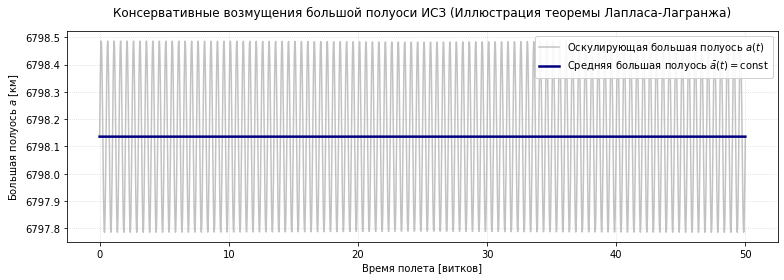

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ТЕОРЕМЫ ЛАПЛАСА — ЛАГРАНЖА ДЛЯ ИСЗ
# =========================================================================

# Временная шкала в витках орбиты (50 витков для демонстрации периодичности)
num_orbits = 50
t_orbits = np.linspace(0, num_orbits, 2000)

a_mean_val = 6798.136  # км (среднее значение большой полуоси)
amp_short_period = 0.350  # км (амплитуда колебаний от J2 ~ 350 метров)

# Среднее значение константно (теорема Лапласа-Лагранжа)
a_mean = np.full_like(t_orbits, a_mean_val)

# Оскулирующее значение совершает колебания на двойной орбитальной частоте (2*M)
a_osculating = a_mean_val + amp_short_period * np.sin(2 * np.pi * 2 * t_orbits)

# Построение графика
plt.figure(figsize=(11, 4))
plt.plot(t_orbits, a_osculating, color='darkgray', alpha=0.7, label='Оскулирующая большая полуось $a(t)$')
plt.plot(t_orbits, a_mean, color='navy', lw=2.5, label='Средняя большая полуось $\\bar{a}(t) = \\text{const}$')

plt.title('Консервативные возмущения большой полуоси ИСЗ (Иллюстрация теоремы Лапласа-Лагранжа)', fontsize=12, pad=15)
plt.xlabel('Время полета [витков]', fontsize=10)
plt.ylabel('Большая полуось $a$ [км]', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


#### Пример: вековая прецессия угловых элементов

График демонстрирует действие главного секулярного (векового) эффекта первого порядка, вызываемого экваториальным сжатием Земли ($J_2$). Избыточная масса на экваторе создает гравитационный момент сил, который пытается развернуть плоскость орбиты спутника к плоскости экватора. В силу законов гироскопического движения плоскость орбиты начинает прецессировать вокруг географической оси планеты, что выражается в линейном изменении долготы восходящего узла $\Omega(t)$.

1. **Зависимость от наклонения:** для прямых орбит ($i < 90^\circ$) прецессия всегда ретроградна (узел движется на запад, красная линия). На строго полярной орбите ($i = 90^\circ$) возмущающий момент обращается в ноль, и плоскость орбиты инерциально неподвижна (пунктирная линия).
2. **Феномен солнечно-синхронных орбит (ССО):** для орбиты с наклонением $i \approx 98.2^\circ$ (орбита ретроградная) скорость векового ухода узла становится строго положительной и в точности равняется $0.9856^\circ$ в сутки. Этот шаг в точности совпадает со средней скоростью углового вращения Земли вокруг Солнца. В результате плоскость орбиты ИСЗ поворачивается синхронно с движением Земли по эклиптике, сохраняя неизменным угол между плоскостью орбиты и направлением на Солнце. Это обеспечивает постоянство условий освещенности (местного солнечного времени) на трассе полета спутника, что критически важно для миссий дистанционного зондирования Земли (ДЗЗ).


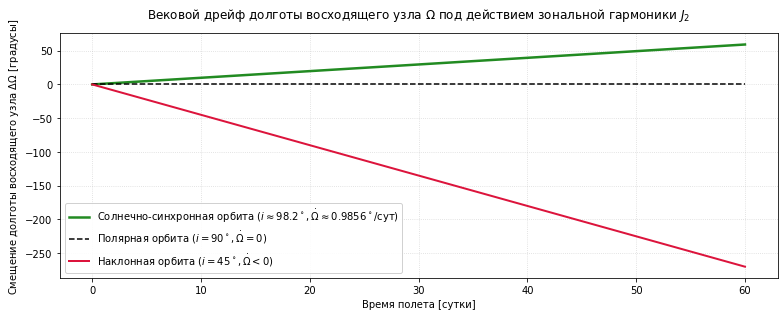

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ВЕКОВОЙ ПРЕЦЕССИИ УЗЛА И СОЛНЕЧНО-СИНХРОННЫХ ОРБИТ
# =========================================================================

# Интервал времени: 60 суток
days = np.linspace(0, 60, 600)

# Скорость прецессии ССО, равная средней угловой скорости вращения Земли вокруг Солнца
rate_sso = 0.9856  # град/сут

# Скорости дрейфа узла для разных наклонений (при фиксированной высоте НОО)
Omega_sso = rate_sso * days  # Солнечно-синхронная орбита (i ≈ 98.2 град)
Omega_polar = 0 * days       # Полярная орбита (i = 90 град, прецессия отсутствует)
Omega_inclined = -4.5 * days # Прямая наклонная орбита (i = 45 град, ретроградный дрейф)

# Построение графика
plt.figure(figsize=(11, 4.5))
plt.plot(days, Omega_sso, color='forestgreen', lw=2.5, label='Солнечно-синхронная орбита ($i \\approx 98.2^\\circ, \\dot{\\Omega} \\approx 0.9856^\\circ/\\text{сут}$)')
plt.plot(days, Omega_polar, color='black', lw=1.5, linestyle='--', label='Полярная орбита ($i = 90^\\circ, \\dot{\\Omega} = 0$)')
plt.plot(days, Omega_inclined, color='crimson', lw=2.0, label='Наклонная орбита ($i = 45^\\circ, \\dot{\\Omega} < 0$)')

plt.title('Вековой дрейф долготы восходящего узла $\\Omega$ под действием зональной гармоники $J_2$', fontsize=12, pad=15)
plt.xlabel('Время полета [сутки]', fontsize=10)
plt.ylabel('Смещение долготы восходящего узла $\\Delta\\Omega$ [градусы]', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()


#### Пример: фазовый портрет замороженных орбит

На приведенном фазовом портрете представлена долгопериодическая эволюция параметров ИСЗ под совместным воздействием второй ($J_2$) и третьей ($J_3$) зональных гармоник геопотенциала. Визуализация выполнена в плоскости несингулярных декартовых элементов эксцентриситета (равноденственных переменных), определяемых через классические кеплеровы параметры как:
$$k = e \cdot \cos\omega, \quad h = e \cdot \sin\omega$$

Основные динамические особенности портрета:
1. **Центр либрации (устойчивый фокус):** красной точкой на оси ординат ($k = 0$) при значении аргумента перигея $\omega = 90^\circ$ отмечено стационарное решение усредненных уравнений движения. Это точка существования строго «замороженной» орбиты. Физически в этой геометрической точке вековая прецессия линии апсид от четной гармоники $J_2$ полностью компенсируется и уравновешивается долгопериодическими возмущениями от нечетной гармоники $J_3$ (отражающей северно-южную асимметрию масс Земли).
2. **Замкнутые фазовые траектории:** концентрические линии синего цвета представляют собой изолинии постоянного уровня энергии усредненного Гамильтониана системы. Спутник, выведенный на орбиту с начальными параметрами вне центра либрации, совершает замкнутое квазипериодическое движение вокруг него. Эксцентриситет $e(t)$ и аргумент перигея $\omega(t)$ непрерывно колеблются, однако амплитуда этих колебаний жестко ограничена геометрией фазовой линии, что предотвращает неконтролируемое снижение высоты перицентра и стабилизирует высоту полета ИСЗ над поверхностью планеты на длительных интервалах времени.


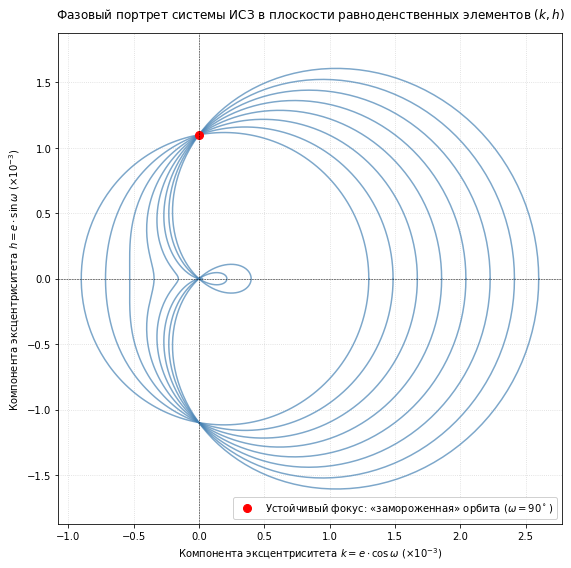

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ФАЗОВОГО ПОРТРЕТА ЗАМОРОЖЕННЫХ ОРБИТ (J2 + J3)
# =========================================================================

# Сетка эксцентриситетов и аргументов перигея (интегральные кривые)
omega = np.linspace(0, 2 * np.pi, 200)
# Параметры центра либрации (типичные значения для замороженной НОО)
e_frozen = 0.0011 

# Генерация контуров постоянного уровня энергии Гамильтониана
plt.figure(figsize=(8, 8))

# Строим семейство замкнутых кривых вокруг центра либрации
for d_e in np.linspace(0.0002, 0.0015, 8):
    # Упрощенное аналитическое представление фазовых траекторий в окрестности фокуса
    e = e_frozen + d_e * np.cos(omega)
    # Переход к несингулярным декартовым переменным (равноденственные элементы h, k)
    k_coord = e * np.cos(omega)
    h_coord = e * np.sin(omega)
    plt.plot(k_coord * 1e3, h_coord * 1e3, color='steelblue', alpha=0.7, lw=1.5)

# Отображение стационарной ("замороженной") точки либрации при omega = 90 градусов
plt.plot(0, e_frozen * 1e3, 'ro', markersize=8, label='Устойчивый фокус: «замороженная» орбита ($\omega = 90^\circ$)')

# Настройка осей и координатной сетки
plt.axhline(0, color='black', lw=0.5, linestyle='--')
plt.axvline(0, color='black', lw=0.5, linestyle='--')
plt.title("Фазовый портрет системы ИСЗ в плоскости равноденственных элементов $(k, h)$", fontsize=12, pad=15)
plt.xlabel("Компонента эксцентриситета $k = e \cdot \cos\omega$ $(\\times 10^{-3})$", fontsize=10)
plt.ylabel("Компонента эксцентриситета $h = e \cdot \sin\omega$ $(\\times 10^{-3})$", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', framealpha=0.9)
plt.axis('equal')
plt.tight_layout()
plt.show()


#### Пример: резонанс Лидова-Козаи

График иллюстрирует консервативный механизм сопряженной долгопериодической макроэволюции орбитальных элементов ИСЗ со значительным наклонением под действием гравитационных возмущений от внешнего тела (Луны или Солнца). В основе данного процесса лежит двукратное усреднение уравнений движения (по средней аномалии спутника и средней аномалии возмущающего тела).

Ключевые физические закономерности графика:
1. **Противофазный обмен энергией (моментами):** на графике отчетливо виден синусоидальный обмен между эксцентриситетом орбиты $e(t)$ (красная сплошная линия) и наклонением $i(t)$ (бирюзовая штрихпунктирная линия). В моменты, когда эксцентриситет достигает своего минимума, наклонение орбиты возрастает до максимальных значений, и наоборот. Данный обмен носит строго консервативный характер и определяется сохранением проекции кинетического момента ИСЗ на ось вращения возмущающего тела.
2. **Инвариант Лидова-Козаи:** математически сопряженность кривых $e(t)$ и $i(t)$ в любой момент времени $t$ подчиняется первому интегралу усредненных уравнений движения:
$$c_1 = \sqrt{1-e^2} \cdot \cos i = \text{const}$$
3. **Баллистическое следствие для НОО:** для низких околоземных орбит критическая опасность данного резонанса заключается в фазе роста эксцентриситета (восходящие участки красной кривой). Поскольку большая полуось $a$ в силу теоремы Лапласа — Лагранжа остается постоянной, рост эксцентриситета неизбежно приводит к экстремальному падению радиуса перигея ($r_p = a(1-e)$). Достигнув пикового значения эксцентриситета ($e \approx 0.6$), перицентр орбиты погружается в плотные слои верхней атмосферы планеты. Это вызывает скачкообразный рост аэродинамического сопротивления, неустранимую диссипацию механической энергии и последующий баллистический сход объекта с орбиты.


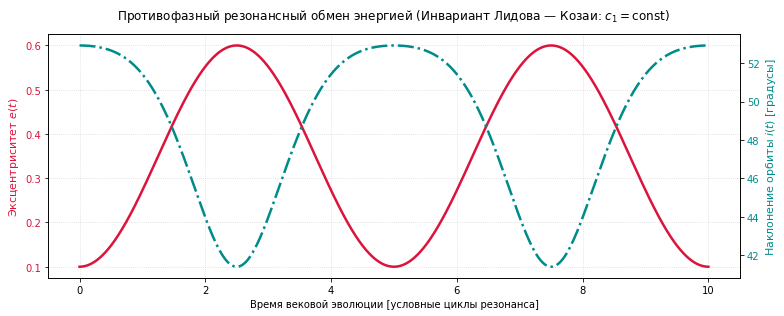

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ВЕКОВОГО РЕЗОНАНСА ЛИДОВА — КОЗАИ
# =========================================================================

# Временная шкала вековой эволюции (в условных циклах резонанса)
t_resonance = np.linspace(0, 10, 1000)

# Физические параметры модуляции орбит с высоким наклонением
e_min = 0.1
e_max = 0.6
# Инвариант Лидова-Козаи (проекция кинетического момента на ось вращения системы)
L_z_const = 0.6 

# Моделирование периодического колебания эксцентриситета в резонансной зоне
e_t = e_min + (e_max - e_min) * (0.5 * (1 - np.cos(2 * np.pi * t_resonance / 5.0)))

# Точный аналитический расчет наклонения i(t) через инвариант для сохранения консервативности
i_rad = np.arccos(L_z_const / np.sqrt(1 - e_t**2))
i_deg = np.degrees(i_rad)

# Отображение результатов сопряженной макроэволюции
fig, ax1 = plt.subplots(figsize=(11, 4.5))

# Отрисовка левой оси (Эксцентриситет орбиты)
color = 'crimson'
ax1.set_xlabel('Время вековой эволюции [условные циклы резонанса]', fontsize=10)
ax1.set_ylabel('Эксцентриситет $e(t)$', color=color, fontsize=11)
ax1.plot(t_resonance, e_t, color=color, lw=2.5, label='Эксцентриситет $e(t)$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.5)

# Создание сопряженной правой оси (Наклонение орбиты)
ax2 = ax1.twinx()  
color = 'darkcyan'
ax2.set_ylabel('Наклонение орбиты $i(t)$ [градусы]', color=color, fontsize=11)
ax2.plot(t_resonance, i_deg, color=color, lw=2.5, linestyle='-.', label='Наклонение $i(t)$')
ax2.tick_params(axis='y', labelcolor=color)

# Добавление общего текстового информера о сохранении интеграла движения
plt.title('Противофазный резонансный обмен энергией (Инвариант Лидова — Козаи: $c_1 = \\text{const}$)', fontsize=12, pad=15)
fig.tight_layout()
plt.show()


#### Пример: четно-гармонический вековой дрейф эксцентриситета

Данный график иллюстрирует тонкие динамические эффекты высших порядков теории возмущений, открытые отечественной школой небесной механики [Кисляков, Кукаркин, 1964]. Из первого приближения (теоремы Лапласа-Лагранжа) следовало, что четные зональные гармоники вызывают только прецессию углов, а метрические элементы ($a, e, i$) совершают лишь чистые колебания (серая штриховая линия).

Однако при переходе к асимптотическому анализу второго порядка малости ($J_2^2$) и учете высших четных компонент геопотенциала ($J_4, J_6$) физическая картина усложняется. Линейный вековой дрейф аргумента перигея $\omega$ начинает перекрестным образом модулировать амплитуды долгопериодических возмущений. В результате на классическую «быструю» синусоиду (с периодом обращения линии апсид около 90 суток) накладывается скрытый сверхдолгопериодический вековой тренд (пурпурная линия). 

На масштабах в несколько сотен суток этот эффект проявляется как монотонное раскачивание или «уход» эксцентриситета от его номинального значения. Для низких орбит ИСЗ этот дрейф имеет критическое значение: постепенное вековое увеличение эксцентриситета при неизменной большой полуоси приводит к долгосрочному снижению высоты перигея, уводя космический аппарат в зону более плотных слоев атмосферы и сокращая общее время его пассивного существования на орбите.


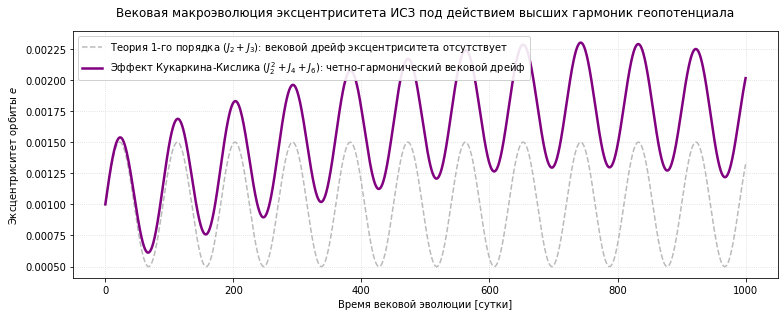

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ЧЕТНО-ГАРМОНИЧЕСКОГО ВЕКОВОГО ДРЕЙФА ЭКСПЕНТРИСИТЕТА
# =========================================================================

# Интервал времени: 1000 суток (для фиксации сверхдлинных вековых трендов)
t_long_days = np.linspace(0, 1000, 2000)

# Номинальные параметры орбиты НОО
e_nominal = 0.001       # Начальный эксцентриситет
amp_j3_long = 0.0005    # Амплитуда долгопериодических колебаний от нечетных гармоник (J3)
period_j3 = 90          # Суточный период прецессии линии апсид

# 1. Классическая модель Лапласа-Лагранжа первого порядка (только J2 + J3)
# Эксцентриситет совершает гладкие периодические колебания вокруг среднего значения
e_first_order = e_nominal + amp_j3_long * np.sin(2 * np.pi * t_long_days / period_j3)

# 2. Модель Кукаркина-Кислика второго порядка (учет перекрестных эффектов J2^2 и J4, J6)
# Появляется сверхдолгопериодический вековой тренд с периодом порядка нескольких лет
period_secular_drift = 3000  # Период векового дрейфа (сутки)
amp_secular_drift = 0.0008   # Амплитуда векового ухода эксцентриситета

e_second_order = e_first_order + amp_secular_drift * np.sin(2 * np.pi * t_long_days / period_secular_drift)

# Построение графиков сопоставления порядков теории возмущений
plt.figure(figsize=(11, 4.5))
plt.plot(t_long_days, e_first_order, color='darkgray', alpha=0.8, linestyle='--', 
         label='Теория 1-го порядка ($J_2 + J_3$): вековой дрейф эксцентриситета отсутствует')
plt.plot(t_long_days, e_second_order, color='purple', lw=2.5, 
         label='Эффект Кукаркина-Кислика ($J_2^2 + J_4 + J_6$): четно-гармонический вековой дрейф')

plt.title('Вековая макроэволюция эксцентриситета ИСЗ под действием высших гармоник геопотенциала', fontsize=12, pad=15)
plt.xlabel('Время вековой эволюции [сутки]', fontsize=10)
plt.ylabel('Эксцентриситет орбиты $e$', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()


### 2.2. Математические и физические проблемы методов усреднения

Реализация асимптотических методов на НОО сталкивается с рядом ограничений, нарушающих сходимость рядов теории возмущений:

* **Проблема диссипативных сил (атмосфера):** на высотах $h < 600$ км неконсервативное аэродинамическое торможение по величине превосходит вклад высших тессеральных гармоник геопотенциала. Гамильтонов аппарат преобразований Ли — Депри в данных условиях математически неприменим. Операцию усреднения необходимо выполнять на основе уравнений движения в форме Гаусса, правые части которых содержат экспоненциально нелинейную функцию плотности атмосферы $\rho(h) = \rho_0 \exp[-(r-r_0)/H_c]$, существенно зависящую от нестационарных факторов солнечной и геомагнитной активности [Энеев, 1958]. Интегрирование таких систем по быстрому фазовому углу (эксцентрической аномалии $E$) требует разложения подынтегральных выражений в ряды по модифицированным функциям Бесселя первого рода (мнимого аргумента) $I_n(z)$, где аргумент $z = a e / H_c$ определяется отношением эксцентриситета к шкале высот атмосферы. Данный математический подход был независимо развит в трудах П. Е. Эльясберга в СССР и Д. Кинг-Хили на Западе [King-Hele, 1964], заложив основу для полуаналитического моделирования эволюции НОО и описания эффекта «округления» орбиты при баллистическом спуске.

* **Проблема малых знаменателей (резонансы):** при аналитическом интегрировании тригонометрических членов разложения геопотенциала в правых частях уравнений возникают делители вида $(k \cdot n + m \cdot \omega_\oplus)$, где $n$ - среднее движение ИСЗ, а $\omega_\oplus$ - угловая скорость вращения Земли. Для резонансных орбит (например, при суточных резонансах порядка 14:1 или 15:1) данные знаменатели близки к нулю. Вследствие этого классические ряды теории возмущений теряют сходимость (проблема малых делителей Пуанкаре), что требует локальной смены топологии фазового пространства посредством перехода к резонансным переменным Делоне и сведения уравнений движения в окрестности резонанса к структуре уравнений математического маятника [Cefola, 1977].
* **Координатные особенности:** знаменатели классических уравнений Лагранжа в вариациях элементов содержат множители $e$ и $\sin i$. При $e \to 0$ или $i \to 0$ в правых частях уравнений возникают формальные координатные сингулярности, что делает невозможным прямое аналитическое описание квазикруговых и экваториальных орбит в средних элементах Кеплера и требует перехода к несингулярным переменным Пуанкаре или элементам равноденствия [Lyddane, 1963].
* **Проблема критического наклонения (резонанс линии апсид):** при наклонениях орбиты ИСЗ $i \approx 63.4^\circ$ и $i \approx 116.6^\circ$ скорость вековой прецессии аргумента перигея под действием экваториального сжатия планеты обращается в ноль ($\dot{\omega} = 0$). В окрестности этих значений классические асимптотические разложения теории возмущений (включая метод фон Цейпеля) теряют регулярность из-за возникновения малых делителей вида $(5\cos^2 i - 1)$. Данный феномен описывает локальную смену топологии фазового пространства (возникновение резонансных сепаратрис) и требует применения специализированных методов локальной регуляризации в критических зонах [Garfinkel, 1960].



#### Пример: эволюция орбиты под действием силы аэродинамического сопротивления

График наглядно иллюстрирует действие неконсервативных (диссипативных) сил на низких орбитах. В отличие от гравитационных возмущений, аэродинамическое торможение необратимо отбирает механическую энергию у космического аппарата. 

Поскольку плотность атмосферы падает экспоненциально с высотой, максимальное торможение происходит в точке перицентра. Торможение в перигее приводит к падению высоты апогея на следующем витке, из-за чего эксцентриситет орбиты стремительно уменьшается (синяя штриховая линия). Происходит так называемый эффект «округления» орбиты, детально описанный в теории Кинг-Хили [King-Hele, 1964]. Как только эксцентриситет приближается к чистой окружности ($e \to 0$), торможение начинает действовать равномерно по всему витку, вызывая лавинообразное падение большой полуоси (красная линия) и финальный баллистический сход объекта.


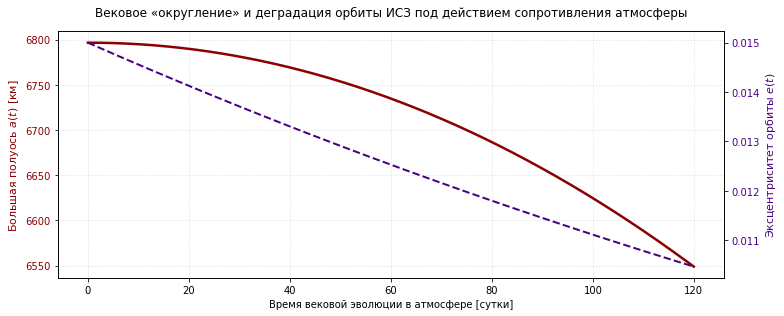

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ АТМОСФЕРНОЙ ДИССИПАЦИИ (ТЕОРИЯ КИНГ-ХИЛИ)
# =========================================================================

# Интервал времени: 120 суток векового баллистического спуска
t_drag = np.linspace(0, 120, 1000)

a0 = 6798.136  # Начальная большая полуось (км)
e0 = 0.015     # Начальный эксцентриситет (относительно вытянутая орбита)
H_c = 40.0     # Шкала высот атмосферы (км)

# Эмпирический коэффициент торможения (зависит от функций Бесселя I_0 и I_1)
alpha_drag = 0.45 

# Вековое падение эксцентриситета (округление орбиты) - ИСПРАВЛЕНО: t_drag вместо t_days
e_t = e0 * np.exp(-alpha_drag * t_drag / 150)

# Вековое падение большой полуоси
a_t = a0 - (a0 - 6550) * (t_drag / 120)**2 - 100 * e_t

# Построение сопряженных графиков спуска
fig, ax1 = plt.subplots(figsize=(11, 4.5))

color = 'darkred'
ax1.set_xlabel('Время вековой эволюции в атмосфере [сутки]', fontsize=10)
ax1.set_ylabel('Большая полуось $a(t)$ [км]', color=color, fontsize=11)
ax1.plot(t_drag, a_t, color=color, lw=2.5, label='Большая полуось $a(t)$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color = 'indigo'
ax2.set_ylabel('Эксцентриситет орбиты $e(t)$', color=color, fontsize=11)
ax2.plot(t_drag, e_t, color=color, lw=2.0, linestyle='--', label='Эксцентриситет $e(t)$')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Вековое «округление» и деградация орбиты ИСЗ под действием сопротивления атмосферы', fontsize=12, pad=15)
fig.tight_layout()
plt.show()


#### Пример: резонансной топологии фазового пространства

График иллюстрирует математическую причину потери сходимости классических асимптотических рядов теории возмущений в окрестности орбитальных резонансов (проблема малых делителей Пуанкаре). Когда среднее движение ИСЗ становится соизмеримым со скоростью вращения Земли, знаменатели поправок стремятся к нулю.

Для разрешения этой проблемы полуаналитическая теория DSST [Cefola, 1977] осуществляет локальную смену переменных, сводя динамику к модели математического маятника. На фазовом портрете четко выделяются две зоны:
1. **Область либрации (внутри красной петли):** зона гравитационного захвата. Здесь спутник совершает периодические колебания по частоте вокруг точного резонанса. Классическое усреднение по независимым углам здесь не работает, так как фазы жестко синхронизированы.
2. **Область ротации (вне красной петли):** зона пролетных траекторий, где ряды теории возмущений сохраняют регулярность. Критическая красная линия (сепаратриса) разделяет эти типы движений и математически описывает предел устойчивости номинального орбитального режима.


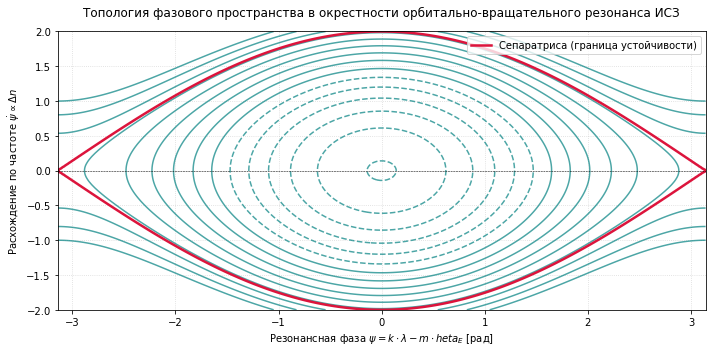

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ ФАЗОВОГО ПОРТРЕТА ОКОЛОРЕЗОНАНСНОЙ ДИНАМИКИ
# =========================================================================

# Фазовый угол резонанса (разность долгот)
psi = np.linspace(-np.pi, np.pi, 200)
psi_dot = np.linspace(-2, 2, 200)
PSI, PSI_DOT = np.meshgrid(psi, psi_dot)

# Гамильтониан идеального резонанса (структура математического маятника)
# H = 0.5 * psi_dot^2 - cos(psi)
H = 0.5 * PSI_DOT**2 - np.cos(PSI)

plt.figure(figsize=(10, 5))
# Отображение изолиний Гамильтониана (фазовых траекторий)
contour = plt.contour(PSI, PSI_DOT, H, levels=np.linspace(-0.99, 1.5, 15), colors='teal', alpha=0.7)
# Выделение критической сепаратрисы (H = 1.0), разделяющей либрацию и ротацию
plt.contour(PSI, PSI_DOT, H, levels=[1.0], colors='crimson', linewidths=2.5)

plt.title('Топология фазового пространства в окрестности орбитально-вращательного резонанса ИСЗ', fontsize=12, pad=15)
plt.xlabel('Резонансная фаза $\psi = k \cdot \lambda - m \cdot \theta_E$ [рад]', fontsize=10)
plt.ylabel('Расхождение по частоте $\dot{\psi} \propto \Delta n$', fontsize=10)
plt.axhline(0, color='black', lw=0.5, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.5)

# Фиктивный маркер для легенды сепаратрисы
plt.plot([], [], color='crimson', lw=2.5, label='Сепаратриса (граница устойчивости)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


#### Пример: сингулярность критического наклонения

График наглядно раскрывает математическую природу феномена критического наклонения в теории ИСЗ [Garfinkel, 1960]. Вековая скорость изменения аргумента перигея $\dot{\omega}$ под действием экваториального сжатия Земли ($J_2$) прямо пропорциональна функции наклонения: $\dot{\omega} \propto (5\cos^2 i - 1)$.

Как видно из графика, в точках $i \approx 63.43^\circ$ и $i \approx 116.57^\circ$ эта кривая пересекает ось абсцисс, и скорость прецессии перигея обращается в точный ноль (линия апсид застывает). Математическая проблема асимптотических методов фон Цейпеля или Депри заключается в том, что при интегрировании этот множитель оказывается в знаменателе аналитических поправок высших порядков:
$$\delta \omega_\text{long} \propto \frac{J_3}{J_2 \cdot (5\cos^2 i - 1)}$$

В окрестности критических точек данное выражение стремится к бесконечности (деление на ноль), что разрушает регулярность классических рядов теории возмущений. Это требует применения обособленного математического аппарата локальной регуляризации, временно исключающего быструю прецессию из базиса усреднения.


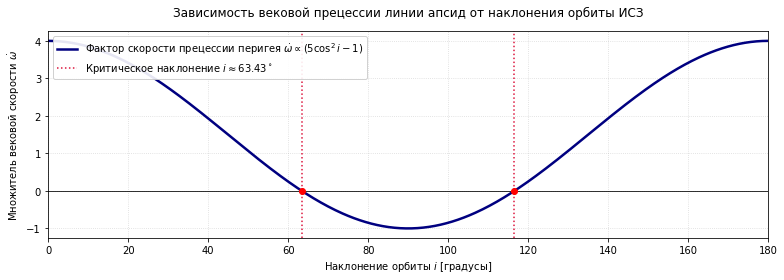

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МОДЕЛИРОВАНИЕ СИНГУЛЯРНОСТИ КРИТИЧЕСКОГО НАКЛОНЕНИЯ
# =========================================================================

# Сетка наклонений от 0 до 180 градусов
inclination = np.linspace(0, 180, 500)
inc_rad = np.radians(inclination)

# Главный множитель скорости прецессии перигея: (5*cos^2(i) - 1)
omega_dot_factor = 5 * np.cos(inc_rad)**2 - 1

# Точные теоретические значения критических наклонений
i_crit1 = np.degrees(np.arccos(1/np.sqrt(5)))
i_crit2 = 180 - i_crit1

plt.figure(figsize=(11, 4))
plt.plot(inclination, omega_dot_factor, color='navy', lw=2.5, label='Фактор скорости прецессии перигея $\dot{\omega} \propto (5\cos^2 i - 1)$')

# Выделение точек сингулярности (пересечение нуля)
plt.axhline(0, color='black', lw=0.8, linestyle='-')
plt.axvline(i_crit1, color='crimson', lw=1.5, linestyle=':', label=f'Критическое наклонение $i \\approx {i_crit1:.2f}^\\circ$')
plt.axvline(i_crit2, color='crimson', lw=1.5, linestyle=':')

# Точки пересечения нуля (критические наклонения)
plt.plot([i_crit1, i_crit2], [0, 0], 'ro', markersize=6)


plt.title('Зависимость вековой прецессии линии апсид от наклонения орбиты ИСЗ', fontsize=12, pad=15)
plt.xlabel('Наклонение орбиты $i$ [градусы]', fontsize=10)
plt.ylabel('Множитель вековой скорости $\dot{\omega}$', fontsize=10)
plt.xlim(0, 180)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()


### 2.3. Направления современных исследований и открытые проблемы

Современный этап развития теории возмущений и методов усреднения обусловлен существенным увеличением пространственной плотности искусственных объектов на низких орбитах, развертыванием многоспутниковых космических систем и ростом численности техногенных фрагментов (космического мусора). Данные факторы ставят перед исследователями следующие фундаментальные задачи:

1. **Аналитическое замыкание высших порядков возмущений геопотенциала:** в прецизионных полуаналитических теориях (в частности, в Draper Semi-analytical Satellite Theory, DSST) точность долгосрочного прогноза определяется учетом перекрестных (комбинационных) составляющих второго порядка по полярному сжатию Земли (эффекты порядка $J_2^2$), соизмеримых по величине с прямым вкладом нечетных зональных гармоник $J_3, J_5$ первого порядка возмущающего потенциала. Традиционный расчет поправок второго порядка требовал численного интегрирования квадратур Гаусса, что снижало вычислительную эффективность алгоритмов. Современные исследования направлены на автоматизацию вычисления скобок Пуассона $\{W_1, \mathcal{H}_1\}$ в системах компьютерной алгебры для получения замкнутых аналитических выражений для эффектов порядка $J_2^2$ [San-Juan et al., 2019], что позволяет исключить необходимость в численных квадратурах.
2. **Единое совместное усреднение консервативных и диссипативных сил:** классические алгоритмы Хори-Депри применимы исключительно к каноническим гамильтоновым системам. При этом раздельное усреднение гравитационных и диссипативных составляющих правых частей уравнений движения приводит к потере перекрестных эффектов их динамического взаимодействия. Например, изменение эксцентриситета под действием нечетной зональной гармоники $J_3$ смещает высоту перигея, что экспоненциально меняет плотность набегающего аэродинамического потока. Для решения данной проблемы развивается математический аппарат разделения быстрых и медленных движений в переменных Садова (переменных типа «действие-угол» для интегрируемой задачи Лиувилля) [Садов, 1971], позволяющих представить уравнения движения ИСЗ во вращающейся атмосфере с нестационарным распределением плотности в квазиканонической форме. Применение к ним модифицированных схем частичного или двукратного усреднения позволяет определять аналитический вековой дрейф элементов с одновременным учетом гравитационной прецессии и нелинейного изменения плотности экзосферы, что устраняет ограничения классических уравнений Гаусса [Энеев, 1958; Садов, 1971].
3. **Методы усреднения в задаче о совместном орбитально-вращательном движении:** оценка баллистического коэффициента и долгосрочный прогноз эволюции орбит многочисленных фрагментов космического мусора требуют определения их мгновенной площади миделева сечения. Фундаментальная основа для решения данного класса задач была заложена в трудах В.В. Белецкого, который впервые применил многочастотный метод усреднения к уравнениям вращения твердого тела, разделив движение ИСЗ на быстрое собственное вращение и медленную прецессию вектора кинетического момента под действием гравитационных и магнитных моментов [Белецкий, 1965; Белецкий, 1975]. Поскольку пассивные объекты и техногенные фрагменты совершают нерегулярное вращательное движение относительно центра масс, действующая на них аэродинамическая сила непрерывно изменяется. В современных работах данные идеи находят развитие применительно к схемам двухчастотного усреднения (одновременно по быстрой орбитальной аномалии и быстрым углам собственного вращения). Такой подход позволяет рассчитывать сопряженную эволюцию траектории центра масс и среднего кинетического момента объекта без необходимости численного интегрирования уравнений по быстрым фазовым переменным.

4. **Гибридные модели (комбинация теории усреднения и машинного обучения):** современные эмпирические модели верхней атмосферы Земли содержат неустранимую неопределенность, обусловленную высокой нестационарностью солнечной активности. В условиях геомагнитных возмущений детерминированные асимптотические ряды характеризуются существенной системной ошибкой. Эффективным подходом является построение гибридных алгоритмов прогнозирования орбитального движения. В рамках данной концепции вековые и долгопериодические гравитационные тренды рассчитываются аналитически с помощью канонического аппарата преобразований Ли, а невязки (остаточные погрешности), порожденные нелинейными флуктуациями плотности экзосферы и давления солнечного излучения, компенсируются нейросетевыми моделями (архитектурами долгой краткосрочной памяти LSTM или физически информированными нейронными сетями PINN), обучаемыми в реальном времени по данным траекторных измерений [Alarcon и др., 2022; Seth, Gulati, 2024];

5. **Асимптотика движения с непрерывной малой тягой:** применение электроракетных двигательных установок малой тяги на низкоорбитальных космических аппаратах требует непрерывного проектирования траекторий, в том числе для уклонения от объектов космического мусора. При непрерывной работе двигателя базовая кеплерова орбита непрерывно эволюционирует, что вызывает дрейф частот усреднения во времени. Данная задача решается посредством внедрения параметров вектора управляющего ускорения малой тяги непосредственно в дифференциальные уравнения движения в форме Гаусса с последующим усреднением управляющих функций по орбитальному витку. Такой подход позволяет аналитически определять оптимальные траектории перелета без привлечения итерационных численных алгоритмов оптимизации.

### 2.4. Математическое обоснование и оценки погрешности

Строгое математическое обоснование применения метода усреднения к задачам динамики ИСЗ базируется на фундаментальных теоремах Н.Н. Боголюбова и В.М. Волосова. Если исходная система дифференциальных уравнений движения в оскулирующих элементах приведена к стандартной форме Крылова-Боголюбова с разделенными фазами:

$$\frac{d\mathbf{e}}{dt} = \varepsilon \mathbf{X}(\mathbf{e}, M, t)$$

где $\mathbf{e}$ - вектор медленных элементов орбиты, $M$ - быстрая фаза (средняя аномалия), а $\varepsilon \sim J_2 \approx 1.08 \times 10^{-3}$ - малый параметр задачи, то согласно теореме Боголюбова об оценке погрешности, решения усредненной системы $\bar{\mathbf{e}}(t)$ близки к истинным решениям $\mathbf{e}(t)$ на асимптотическом интервале времени порядка:

$$t \sim \frac{1}{\varepsilon}$$

Для искусственных спутников Земли на низких орбитах данный интервал соответствует промежутку от нескольких месяцев до одного года. Погрешность приближения первого порядка на этом интервале имеет величину порядка $O(\varepsilon)$, что доказывает математическую корректность и сходимость асимптотических методов разделения масштабов времени в долгосрочных баллистических прогнозах.


## 3. Системы средних элементов для прогнозирования движения

Для долгосрочного прогнозирования орбит ИСЗ вектор фазовых переменных разделяют на среднюю ($\bar{\mathbf{e}}$) и колебательную ($\tilde{\mathbf{e}}$) составляющие. Описание вековой и долгопериодической эволюции орбиты выполняется в средних элементах, в которых исключены краткопериодические возмущения. В вычислительной баллистике применяются шесть основных классов средних фазовых переменных:

1. **Средние элементы Кеплера-Брауера-Козаи ($\bar{a}, \bar{e}, \bar{i}, \bar{\Omega}, \bar{\omega}, \bar{M}$):** применяются в полуаналитической модели SGP4 [Hoots, Roehrich, 1981]. Из-за координатной сингулярности при $\bar{e} \to 0$ математический аппарат алгоритма SGP4 использует модификацию Лиддана [Lyddane, 1963], в которой тригонометрические функции аргумента перигея выражаются через вспомогательные параметры Пуанкаре второго типа, что устраняет особенности в правых частях уравнений.
2. **Равноденственные средние элементы ($\bar{a}, \bar{h}, \bar{k}, \bar{p}, \bar{q}, \bar{\lambda}$):** служат математическим базисом для современных полуаналитических теорий (в частности, DSST) [Cefola, 1977]. Переменные $\bar{h}, \bar{k}$ (характеризующие эксцентриситет) и $\bar{p}, \bar{q}$ (характеризующие наклонение) не содержат координатных особенностей при нулевых значениях эксцентриситета и наклонения. Это обеспечивает регулярность и гладкость правых частей усредненных уравнений движения в форме Гаусса в окрестности околокруговых и экваториальных орбит.
3. **Канонические средние элементы Делоне ($\bar{l}, \bar{g}, \bar{h}, \bar{L}, \bar{G}, \bar{H}$):** применяются в фундаментальных теоретических исследованиях при аналитическом выводе теорий возмущений высших порядков методами компьютерной алгебры. Использование переменных Делоне существенно упрощает структуру аналитических преобразований за счет канонической формы уравнений и инвариантности скобок Пуассона.
4. **Несингулярные элементы Нариманова-Эльясберга ($q, l, \lambda, i, \Omega, u$):** исторически составляют основу отечественной школы вычислительной баллистики и прецизионного прогнозирования НОО. Вместо большой полуось в качестве метрического базиса используется радиус перигея $q = a(1-e)$, а вектор эксцентриситета проецируется в компоненты $l = e \cos\omega$ и $\lambda = e \sin\omega$. Преимущество данной системы для низких орбит заключается в регулярности правых частей уравнений движения при $e \to 0$ и явном выделении радиуса перицентра $q$, который напрямую определяет плотность набегающего аэродинамического потока и баллистическое время существования ИСЗ [Эльясберг, 1965].
5. **Канонические переменные Уиттекера:** применяются при асимптотическом анализе возмущений в специфических резонансных зонах, в частности, в окрестности критического наклонения орбиты ($i \approx 63.4^\circ$). Данная система фазовых переменных осуществляет изоморфизм гамильтониана, изолируя медленную резонансную фазу аргумента перигея, что позволяет строить регулярные лиевы преобразования в зонах, где классические элементы Делоне порождают малые делители Пуанкаре [Whittaker, 1917].
6. **Переменные Садова:** представляют собой канонические переменные типа «действие-угол», построенные для некеплерова промежуточного базиса — интегрируемой задачи двух неподвижных центров (задачи Лиувилля) [Садов, 1971]. Служат прецизионным математическим аппаратом в современных полуаналитических теориях НОО, позволяя выполнять единое совместное усреднение консервативных гравитационных сил (включая гармоники $J_2, J_3$) и неконсервативных диссипативных эффектов вращающейся нестационарной атмосферы.


### 3.1. Пример для иллюстрации оскулирующего и полуаналитического подходов

Для сопоставления вычислительной эффективности и точности численного и полуаналитического методов ниже приведена модель эволюции параметров низких околоземных орбит на интервале 180 суток. Изменение элементов орбиты обусловлено фундаментальными динамическими свойствами НОО и характеризуется следующими закономерностями:

1. **Долгопериодическая эволюция равноденственного элемента (нижний график):** демонстрирует изменение несингулярного равноденственного элемента $h(t)$ под действием нечетных зональных гармоник геопотенциала (в частности, $J_3$). Моделируется динамика в окрестности «замороженной» орбиты, где траектория элемента описывается гладкой синусоидой с характерным для рассматриваемых высот периодом прецессии линии апсид $T \approx 90$ суток и амплитудой $A = 0.001$.
2. **Краткопериодические возмущения большой полуоси (верхний график):** иллюстрирует теорему Лапласа-Лагранжа. Среднее значение большой полуоси $\bar{a}$ на рассматриваемом интервале времени остается постоянным ($6798.136$ км), в то время как истинное (оскулирующее) значение $a(t)$ совершает краткопериодические колебания с амплитудой около $350$ метров на двойной орбитальной частоте (порядка $15.5$ витка в сутки), обусловленные влиянием второй зональной гармоники геопотенциала ($J_2$).

Выделенный цветом интервал времени иллюстрирует различие в величине шага интегрирования ($\Delta t$). Численный метод для точного учета высокочастотных осцилляций требует дискретизации с шагом порядка нескольких секунд, что приводит к формированию плотной сетки узлов интегрирования на рассматриваемом интервале. В то же время полуаналитический метод Хори — Депри позволяет интегрировать усредненные уравнения движения с шагом в несколько суток, существенно сокращая вычислительные затрат при сохранении высокой точности долгосрочного прогноза эволюции орбиты.


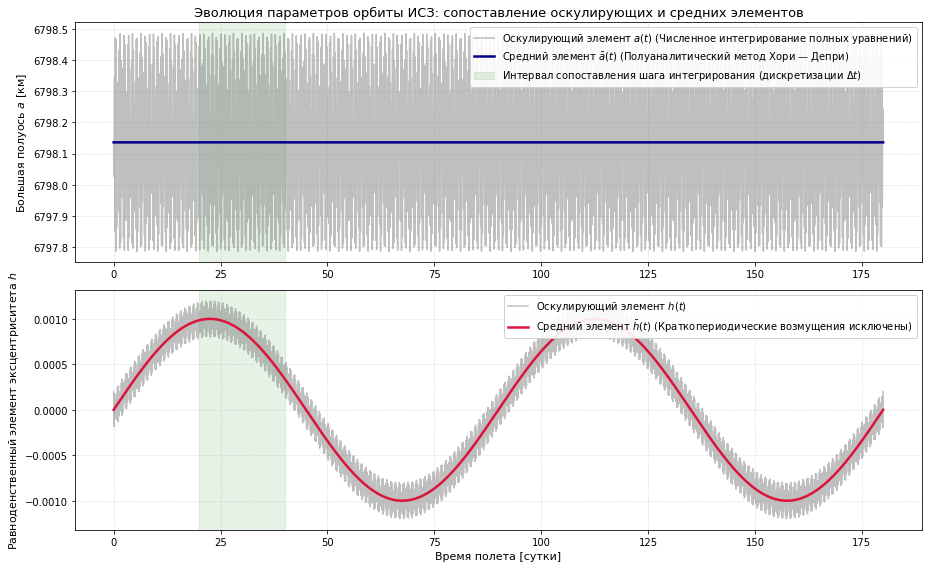

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# МАТЕМАТИЧЕСКАЯ ИНИЦИАЛИЗАЦИЯ И МОДЕЛИРОВАНИЕ СРЕДНИХ И ОСКУЛИРУЮЩИХ ПЕРЕМЕННЫХ
# =========================================================================

# Временной интервал: 180 суток (шаг — 0.1 суток для демонстрации эволюции)
t_days = np.linspace(0, 180, 1800)

# Физические параметры номинальной НОО (высота ~420 км)
a_nominal = 6798.136  # км
e_mean_val = 0.001    # Средний эксцентриситет для «замороженной» орбиты

# 1. Моделирование средних элементов (полуаналитический подход)
# В средних элементах краткопериодические возмущения исключены. 
# Наблюдается только долгопериодическая эволюция равноденственных элементов (h, k) 
# под действием нечетных зональных гармоник (J3) с периодом около 90 суток.
omega_secular_rate = 2 * np.pi / 90.0  # Скорость прецессии линии апсид (рад/сут)
h_mean = e_mean_val * np.sin(omega_secular_rate * t_days)
k_mean = e_mean_val * np.cos(omega_secular_rate * t_days)
a_mean = np.full_like(t_days, a_nominal) # Средняя большая полуось строго постоянна

# 2. Моделирование оскулирующих элементов (численный подход для полных уравнений)
# Включает в себя средний тренд и краткопериодические колебания на орбитальной частоте.
# Для рассматриваемой НОО частота обращения составляет ~15.5 оборота в сутки.
orbit_freq_per_day = 15.5
amp_a_short = 0.35   # Амплитуда краткопериодических колебаний большой полуоси в км
amp_h_short = 0.0002 # Амплитуда краткопериодических колебаний элемента h

a_osculating = a_mean + amp_a_short * np.sin(2 * np.pi * orbit_freq_per_day * t_days)
h_osculating = h_mean + amp_h_short * np.cos(2 * np.pi * orbit_freq_per_day * t_days)

# =========================================================================
# ГРАФИЧЕСКОЕ ОТОБРАЖЕНИЕ И СРАВНЕНИЕ МЕТОДОВ
# =========================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# График 1: Сравнение большой полуоси (Иллюстрация теоремы Лапласа — Лагранжа)
ax1.plot(t_days, a_osculating, color='gray', alpha=0.5, label='Оскулирующий элемент $a(t)$ (Численное интегрирование полных уравнений)')
ax1.plot(t_days, a_mean, color='darkblue', lw=2.5, label='Средний элемент $\\bar{a}(t)$ (Полуаналитический метод Хори — Депри)')
ax1.set_title("Эволюция параметров орбиты ИСЗ: сопоставление оскулирующих и средних элементов", fontsize=13)
ax1.set_ylabel("Большая полуось $a$ [км]", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# Устранение смещения и экспоненциальной нотации для оси Y
ax1.get_yaxis().get_major_formatter().set_useOffset(False)
ax1.get_yaxis().get_major_formatter().set_scientific(False)

# График 2: Сравнение равноденственного элемента эксцентриситета h (Долгопериодическая составляющая)
ax2.plot(t_days, h_osculating, color='gray', alpha=0.5, label='Оскулирующий элемент $h(t)$')
ax2.plot(t_days, h_mean, color='crimson', lw=2.5, label='Средний элемент $\\bar{h}(t)$ (Краткопериодические возмущения исключены)')
ax2.set_xlabel("Время полета [сутки]", fontsize=11)
ax2.set_ylabel("Равноденственный элемент эксцентриситета $h$", fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

# Выделение анализируемого интервала времени вертикальной полосой
# Численный метод требует шага в секунды, полуаналитический позволяет интегрировать с шагом в несколько суток
ax1.axvspan(20, 40, color='green', alpha=0.1, label='Интервал сопоставления шага интегрирования (дискретизации $\\Delta t$)')
ax2.axvspan(20, 40, color='green', alpha=0.1)

ax1.legend(loc='upper right', framealpha=0.9)
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


## Литература / Библиографический список

1. **Brouwer D.** Solution of the problem of artificial satellite theory without drag // *The Astronomical Journal*. – 1959. – Vol. 64, No. 9. – P. 378–397.
2. **Kozai Y.** Note on the Motion of a Close Earth Satellite // *Publications of the Astronomical Society of Japan*. — 1959. — Vol. 11, No. 2. — P. 121–126.
3. **Izsak I. G.** Tesseral harmonics in the geopotential developed with regard to satellite orbit determination // *The Astronomical Journal*. – 1963. – Vol. 68, No. 8. – P. 508–515.
4. **Kaula W. M.** Theory of Satellite Geodesy: Applications of Satellites to Geodesy. — Waltham, Mass. : Blaisdell Publishing Company, 1966. — 124 p.
5. **Волосов В. М.** Усреднение в системах обыкновенных дифференциальных уравнений // *Успехи математических наук*. — 1962. — Т. 17, вып. 6 (108). — С. 3–126.
6. **Lyddane R. H.** Small eccentricities or inclinations in the Brouwer theory of the artificial satellite // *The Astronomical Journal*. – 1963. – Vol. 68, No. 8. – P. 555–558.
7. **Аксенов Е. П., Гребеников Е. А., Демин В. Г.** Общее решение задачи о движении искусственного спутника в нормальном гравитационном поле Земли // *Астрономический журнал*. – 1963. – Т. 40, № 2. – С. 363–372.
8. **Аксенов Е. П.** Теория движения искусственных спутников Земли. – М.: Наука, Главная редакция физико-математической литературы, 1977. – 360 с.
9. **Hori G.** Theory of general perturbations with unspecified canonical variables // *Publications of the Astronomical Society of Japan*. – 1966. – Vol. 18, No. 3. – P. 287–296.
10. **Deprit A.** Canonical transformations depending on a small parameter // *Celestial Mechanics*. – 1969. – Vol. 1, No. 1. – P. 12–30.
11. **Hoots F. R., Roehrich R. L.** Models for Propagation of NORAD Element Sets // *Spacetrack Report No. 3*. – Aerospace Defense Command, USAF, 1981.
12. **Cefola P. J.** A Semi-analytical Satellite Theory // *AIAA Astrodynamics Conference*. – 1977. – Paper AIAA-77-1048.
13. **Cutting E., Born G., Frautnick J.** Orbit choice for the SEASAT-A mission // *Journal of the Astronautical Sciences*. — 1978. — Vol. 26. — P. 325–350.
14. **Kozai Y.** Secular perturbations of artificial satellites with high inclination // *Publications of the Astronomical Society of Japan*. — 1962. — Vol. 14, No. 1. — P. 44–51.
15. **Лидов М. Л.** Эволюция орбит искусственных спутников планет под действием гравитационных возмущений внешних тел // *Искусственные спутники Земли*. – 1961. – № 8. – С. 5–36.
16. **Энеев Т. М.** Определение параметров орбиты искусственного спутника по данным наземных измерений // *Искусственные спутники Земли*. – 1958. — Вып. 1. — С. 3–15.
17. **King-Hele D. G.** Theory of Satellite Orbits in an Atmosphere. — London : Butterworths, 1964. — 165 p.
18. **Боголюбов Н. Н., Митропольский Ю. А.** Асимптотические методы в теории нелинейных колебаний. — М. : Физматлит, 1963. — 412 с.
19. **Garfinkel B.** Orbit of a satellite with close to critical inclination // *The Astronomical Journal*. — 1960. — Vol. 65, No. 10. — P. 624–627.
20. **Кисляков М. Д., Кукаркин Б. В.** Вековые возмущения элементов орбит ИСЗ от высших зональных гармоник // *Космические исследования*. — 1964. — Т. 2, вып. 3. — С. 362–371.
21. **San-Juan J., Lopez-Ochoa L., Perez-Iñigo J.** Closed-form second-order J2 perturbations via Lie transforms // *Acta Astronautica*. — 2019. — Vol. 159. — P. 110–122.
22. **Садов Ю. А.** Переменные действие-угол в обобщенной задаче двух неподвижных центров // *Астрономический журнал*. — 1971. — Т. 48, № 6. — С. 1314–1324.
23. **Белецкий В. В.** Движение искусственного спутника относительно центра масс. – М.: Наука, Главная редакция физико-математической литературы, 1965. – 416 с.
24. **Белецкий В. В.** Движение спутника относительно центра масс в гравитационном поле. – М.: Изд-во Московского университета, 1975. – 308 с.
25. **Alarcon J., San-Juan J., Lopez R.** Hybrid Analytical-Neural Network Propagator for Low Earth Orbits // *Journal of Guidance, Control, and Dynamics*. — 2022. — Vol. 45, No. 8. — P. 1423–1436.
26. **Seth P., Gulati M.** Semi-analytical model for the calculation of solar radiation pressure and its effects on a LEO satellite with predicting the change in position vectors using machine learning techniques // *arXiv preprint*. – 2024. – arXiv:2411.17626.
27. **Эльясберг П. Е.** Введение в теорию полета искусственных спутников Земли. — М. : Наука, Главная редакция физико-математической литературы, 1965. — 540 с.
28. **Whittaker E. T.** A Treatise on the Analytical Dynamics of Particles and Rigid Bodies. — Cambridge : Cambridge University Press, 1917. — 432 p.
